In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


df = pd.read_csv('data/college_sleep_and_gpa.csv')

In [2]:
df.head()

,student_id,study,university,semester,cohort_code,gender,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,...,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep,sleep_bracket,sleep_midpoint_clock
0,293,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,370.0,6.17,...,0.0500,0.931,4.00,3.76,-0.24,49.0,0.112,0,6-6.5h,07:20
1,294,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,406.8,6.78,...,0.0476,0.862,4.00,3.55,-0.45,49.0,0.112,0,6.5-7h,05:00
2,297,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,253.8,4.23,...,0.1639,0.586,3.00,3.59,0.59,46.0,-0.604,1,<5.5h,05:38
3,303,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,411.9,6.86,...,0.7854,0.931,3.80,3.46,-0.34,39.0,-2.275,0,6.5-7h,07:52
4,304,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,408.1,6.80,...,0.1538,0.931,3.17,3.50,0.33,39.0,-2.275,0,6.5-7h,04:54


In [3]:
df.dtypes

student_id                   int64
study                        int64
university                  object
semester                    object
cohort_code                 object
gender                      object
first_generation           float64
underrepresented           float64
avg_sleep_minutes          float64
avg_sleep_hours            float64
daytime_sleep_minutes      float64
sleep_midpoint_minutes     float64
bedtime_variability        float64
nights_tracked_fraction    float64
prior_gpa                  float64
term_gpa                   float64
gpa_change                 float64
term_units                 float64
term_load_z                float64
under_6h_sleep               int64
sleep_bracket               object
sleep_midpoint_clock        object
dtype: object

In [4]:
df.isnull().sum()

student_id                   0
study                        0
university                   0
semester                     0
cohort_code                  0
gender                       3
first_generation             4
underrepresented             1
avg_sleep_minutes            0
avg_sleep_hours              0
daytime_sleep_minutes        0
sleep_midpoint_minutes       0
bedtime_variability          0
nights_tracked_fraction      0
prior_gpa                    0
term_gpa                     0
gpa_change                   0
term_units                 147
term_load_z                147
under_6h_sleep               0
sleep_bracket                0
sleep_midpoint_clock         0
dtype: int64

In [5]:
df.columns

Index(['student_id', 'study', 'university', 'semester', 'cohort_code',
       'gender', 'first_generation', 'underrepresented', 'avg_sleep_minutes',
       'avg_sleep_hours', 'daytime_sleep_minutes', 'sleep_midpoint_minutes',
       'bedtime_variability', 'nights_tracked_fraction', 'prior_gpa',
       'term_gpa', 'gpa_change', 'term_units', 'term_load_z', 'under_6h_sleep',
       'sleep_bracket', 'sleep_midpoint_clock'],
      dtype='object')

In [6]:
clean_df = df[['student_id', 'university', 'gender', 'first_generation', 'avg_sleep_minutes', 'avg_sleep_hours', 'daytime_sleep_minutes', 'prior_gpa', 'term_gpa', 'gpa_change', 'term_units']]

In [7]:
clean_df.columns

Index(['student_id', 'university', 'gender', 'first_generation',
       'avg_sleep_minutes', 'avg_sleep_hours', 'daytime_sleep_minutes',
       'prior_gpa', 'term_gpa', 'gpa_change', 'term_units'],
      dtype='object')

Is there a postiive or negative correlation from the amount of sleep a student gets (avg_sleep_minutes) and the gpa (term_gpa) that they finish the term with. 

In [8]:
clean_df.isnull().sum()

student_id                 0
university                 0
gender                     3
first_generation           4
avg_sleep_minutes          0
avg_sleep_hours            0
daytime_sleep_minutes      0
prior_gpa                  0
term_gpa                   0
gpa_change                 0
term_units               147
dtype: int64

In [9]:
df.shape

(634, 22)

In [10]:
df['avg_sleep_hours'].describe()

count    634.000000
mean       6.622098
std        0.847741
min        3.250000
25%        6.112500
50%        6.675000
75%        7.170000
max        9.790000
Name: avg_sleep_hours, dtype: float64

In [11]:
# making a loop to categorize the hours into bins

def loopy(hours):
    if 3 <= hours <= 5:
        return 'bad'
    elif 5 <= hours <= 7:
        return 'good'
    else:
        return 'great'



In [23]:
# making a new column from the loop

df['sleep_classification'] = df['avg_sleep_hours'].apply(loopy).copy()

In [24]:
df.head()

,student_id,study,university,semester,cohort_code,gender,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,...,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep,sleep_bracket,sleep_midpoint_clock,sleep,sleep_classification
0,293,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,370.0,6.17,...,4.00,3.76,-0.24,49.0,0.112,0,6-6.5h,07:20,good,good
1,294,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,406.8,6.78,...,4.00,3.55,-0.45,49.0,0.112,0,6.5-7h,05:00,good,good
2,297,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,253.8,4.23,...,3.00,3.59,0.59,46.0,-0.604,1,<5.5h,05:38,bad,bad
3,303,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,411.9,6.86,...,3.80,3.46,-0.34,39.0,-2.275,0,6.5-7h,07:52,good,good
4,304,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,408.1,6.80,...,3.17,3.50,0.33,39.0,-2.275,0,6.5-7h,04:54,good,good


In [28]:
sorted = df[[
    'student_id', 'university', 'gender', 'first_generation', 
    'avg_sleep_minutes', 'avg_sleep_hours', 'daytime_sleep_minutes', 
    'prior_gpa', 'term_gpa', 'gpa_change', 'sleep_classification']].copy()

In [29]:
sorted

,student_id,university,gender,first_generation,avg_sleep_minutes,avg_sleep_hours,daytime_sleep_minutes,prior_gpa,term_gpa,gpa_change,sleep_classification
0,293,Carnegie Mellon University,Female,0.0,370.0,6.17,11.7,4.00,3.76,-0.24,good
1,294,Carnegie Mellon University,Female,0.0,406.8,6.78,49.7,4.00,3.55,-0.45,good
2,297,Carnegie Mellon University,Female,0.0,253.8,4.23,178.5,3.00,3.59,0.59,bad
3,303,Carnegie Mellon University,Female,0.0,411.9,6.86,26.1,3.80,3.46,-0.34,good
4,304,Carnegie Mellon University,Female,0.0,408.1,6.80,71.6,3.17,3.50,0.33,good
...,...,...,...,...,...,...,...,...,...,...,...
629,347,Carnegie Mellon University,Female,0.0,445.6,7.43,31.9,3.74,3.74,0.00,great
630,349,Carnegie Mellon University,Female,0.0,430.8,7.18,18.6,3.44,3.61,0.17,great
631,353,Carnegie Mellon University,Female,0.0,360.9,6.01,22.1,3.62,3.81,0.19,good
632,356,Carnegie Mellon University,Male,0.0,303.8,5.06,11.9,3.22,1.38,-1.84,good


In [30]:
classified_sleep = sorted.groupby(['sleep_classification', 'university']).agg({
    'term_gpa': 'mean',
    'avg_sleep_hours': 'mean',
    'daytime_sleep_minutes' : 'mean'
})

reset_classified = classified_sleep.reset_index()

reset_classified

,sleep_classification,university,term_gpa,avg_sleep_hours,daytime_sleep_minutes
0,bad,Carnegie Mellon University,3.140000,4.548182,72.900000
1,bad,University of Notre Dame,3.574571,4.627143,76.685714
2,bad,University of Washington,2.721000,4.451667,107.766667
3,good,Carnegie Mellon University,3.350423,6.233521,31.343662
4,good,University of Notre Dame,3.643846,6.182885,46.425000
5,good,University of Washington,3.368475,6.420750,48.665625
6,great,Carnegie Mellon University,3.402364,7.382364,27.249091
7,great,University of Notre Dame,3.741833,7.450833,35.294444
8,great,University of Washington,3.501221,7.606372,37.866372


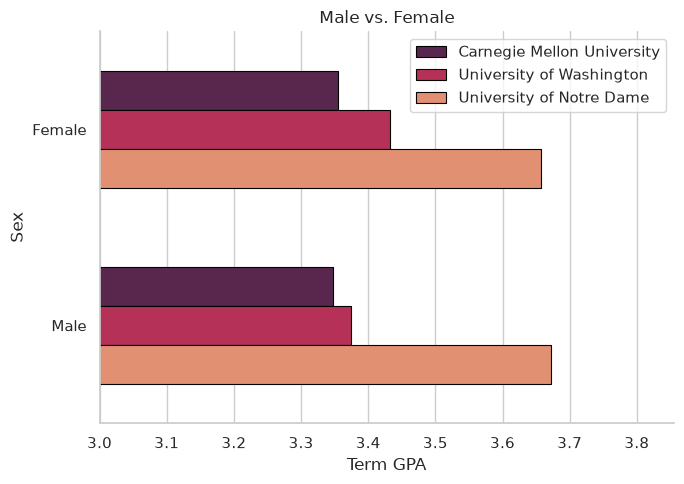

In [14]:

# 1. Set a clean theme
sns.set_theme(style="whitegrid", font_scale=1)

# 2. Create the figure with good proportions
plt.figure(figsize = (7, 5))

# 3. Plot with a nice palette
sns.barplot(
    data=df,
    x='term_gpa',
    y='gender',
    hue='university',    
    errorbar = None,   
    palette='rocket',      
    edgecolor='black',
    linewidth=0.8,
    width=0.6
)

plt.xlim(3.0, )
plt.legend(loc = 'upper right')
plt.title('Male vs. Female')
plt.ylabel('Sex')
plt.xlabel('Term GPA')

sns.despine(top=True, right=True)



plt.tight_layout()
plt.show()

In [31]:
reset_classified

,sleep_classification,university,term_gpa,avg_sleep_hours,daytime_sleep_minutes
0,bad,Carnegie Mellon University,3.140000,4.548182,72.900000
1,bad,University of Notre Dame,3.574571,4.627143,76.685714
2,bad,University of Washington,2.721000,4.451667,107.766667
3,good,Carnegie Mellon University,3.350423,6.233521,31.343662
4,good,University of Notre Dame,3.643846,6.182885,46.425000
5,good,University of Washington,3.368475,6.420750,48.665625
6,great,Carnegie Mellon University,3.402364,7.382364,27.249091
7,great,University of Notre Dame,3.741833,7.450833,35.294444
8,great,University of Washington,3.501221,7.606372,37.866372


In [32]:
def gradey(grade):
    if 2.7 <= grade < 3:
        return 'B-'
    elif 3 <= grade < 3.3:
        return 'B'
    elif 3.3 <= grade < 3.7:
        return 'B+'
    elif 3.7 <= grade < 4 :
        return 'A-'
    else:
        return 'A'



In [33]:
reset_classified['letter_grade'] = reset_classified['term_gpa'].apply(gradey)

In [34]:
reset_classified

,sleep_classification,university,term_gpa,avg_sleep_hours,daytime_sleep_minutes,letter_grade
0,bad,Carnegie Mellon University,3.140000,4.548182,72.900000,B
1,bad,University of Notre Dame,3.574571,4.627143,76.685714,B+
2,bad,University of Washington,2.721000,4.451667,107.766667,B-
3,good,Carnegie Mellon University,3.350423,6.233521,31.343662,B+
4,good,University of Notre Dame,3.643846,6.182885,46.425000,B+
5,good,University of Washington,3.368475,6.420750,48.665625,B+
6,great,Carnegie Mellon University,3.402364,7.382364,27.249091,B+
7,great,University of Notre Dame,3.741833,7.450833,35.294444,A-
8,great,University of Washington,3.501221,7.606372,37.866372,B+


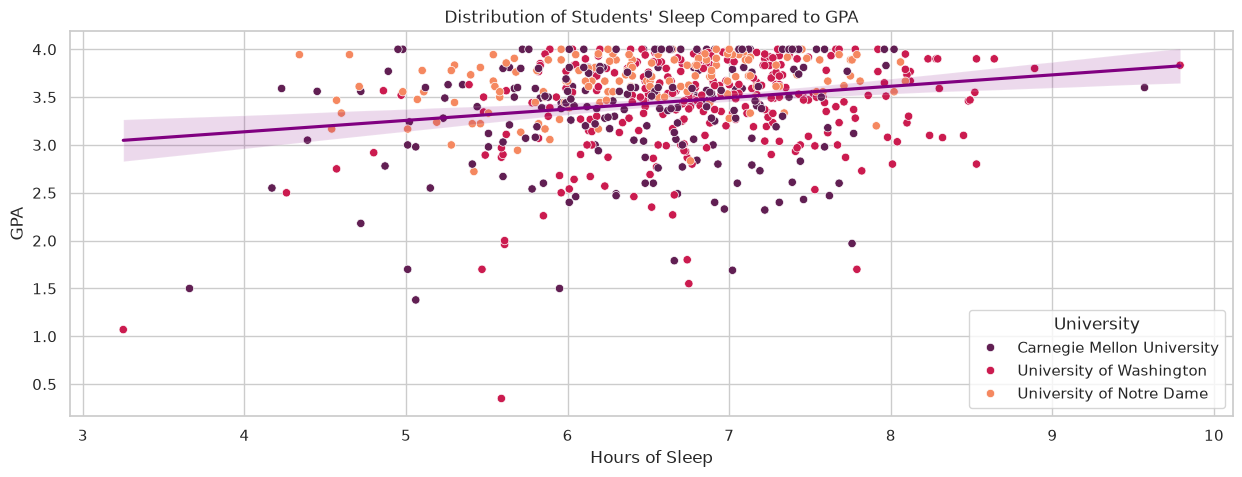

In [ ]:
plt.figure(figsize=(15,5))


sns.scatterplot(
    data = sorted,
    x = 'avg_sleep_hours',
    y = 'term_gpa',
    hue='university', 
    palette='rocket'
)

sns.regplot(
    data=sorted,
    x='avg_sleep_hours',
    y='term_gpa',
    scatter=False,
    color='purple'
)

plt.legend(title='University')
plt.xlabel('Hours of Sleep')
plt.ylabel('GPA')
plt.title("Distribution of Students' Sleep Compared to GPA")
plt.show()
